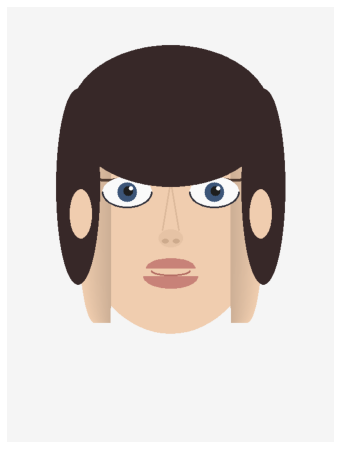

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 画布 600×800，浅色背景
img = np.ones((800, 600, 3), dtype=np.uint8) * 245
cx, cy = 300, 380  # 脸部中心

# ========== 1. 脸部基底 + 肤色渐变 ==========
# 主肤色（黄种人BGR：偏暖调）
skin_base = (175, 205, 240)
# 脸部椭圆轮廓
cv2.ellipse(img, (cx, cy), (170, 220), 0, 0, 360, skin_base, -1)

# 脸部两侧阴影，模拟脸部立体感
for i in range(30):
    alpha = i / 30
    color = (int(175 - 25*alpha), int(205 - 30*alpha), int(240 - 35*alpha))
    cv2.ellipse(img, (cx - 140 + i, cy), (30 - i, 200), 0, 0, 360, color, -1)
    cv2.ellipse(img, (cx + 140 - i, cy), (30 - i, 200), 0, 0, 360, color, -1)

# 额头高光
for i in range(20):
    alpha = i / 20
    color = (int(185 + 10*alpha), int(215 + 10*alpha), int(245 + 10*alpha))
    cv2.ellipse(img, (cx, cy - 160 + i), (100, 20 - i), 0, 0, 360, color, -1)

# ========== 2. 眉毛 ==========
brow_color = (50, 60, 80)
# 左眉
cv2.ellipse(img, (cx - 80, cy - 80), (55, 12), -15, 0, 180, brow_color, 3)
# 右眉
cv2.ellipse(img, (cx + 80, cy - 80), (55, 12), 15, 0, 180, brow_color, 3)

# ========== 3. 眼睛 ==========
eye_white = (250, 250, 250)
iris_color = (120, 85, 60)  # 棕褐色虹膜
pupil_color = (30, 30, 30)
highlight = (255, 255, 255)

# 左眼
cv2.ellipse(img, (cx - 80, cy - 40), (45, 28), 0, 0, 360, eye_white, -1)
cv2.circle(img, (cx - 80, cy - 40), 18, iris_color, -1)
cv2.circle(img, (cx - 78, cy - 42), 9, pupil_color, -1)
cv2.circle(img, (cx - 73, cy - 47), 4, highlight, -1)
# 上眼睑弧线（改用ellipse画上半圆弧：start=0 end=180）
cv2.ellipse(img, (cx - 80, cy - 40), (45, 28), 0, 0, 180, (60, 50, 50), 2)

# 右眼
cv2.ellipse(img, (cx + 80, cy - 40), (45, 28), 0, 0, 360, eye_white, -1)
cv2.circle(img, (cx + 80, cy - 40), 18, iris_color, -1)
cv2.circle(img, (cx + 82, cy - 42), 9, pupil_color, -1)
cv2.circle(img, (cx + 87, cy - 47), 4, highlight, -1)
# 上眼睑弧线
cv2.ellipse(img, (cx + 80, cy - 40), (45, 28), 0, 0, 180, (60, 50, 50), 2)

# ========== 4. 鼻子 ==========
nose_shadow = (155, 185, 220)
# 鼻梁
cv2.line(img, (cx, cy - 60), (cx - 15, cy + 30), nose_shadow, 2)
cv2.line(img, (cx, cy - 60), (cx + 15, cy + 30), nose_shadow, 2)
# 鼻头
cv2.ellipse(img, (cx, cy + 45), (22, 16), 0, 0, 360, (165, 195, 230), -1)
# 鼻孔
cv2.ellipse(img, (cx - 10, cy + 50), (6, 4), 0, 0, 360, (140, 170, 205), -1)
cv2.ellipse(img, (cx + 10, cy + 50), (6, 4), 0, 0, 360, (140, 170, 205), -1)

# ========== 5. 嘴唇 ==========
lip_color = (120, 130, 200)
lip_dark = (100, 110, 180)
# 上唇
cv2.ellipse(img, (cx, cy + 100), (45, 18), 0, 180, 360, lip_color, -1)
# 下唇
cv2.ellipse(img, (cx, cy + 115), (50, 22), 0, 0, 180, lip_color, -1)
# 唇缝
cv2.ellipse(img, (cx, cy + 105), (35, 8), 0, 0, 180, lip_dark, 2)

# ========== 6. 头发 ==========
hair_color = (40, 40, 55)
# 头发主体
cv2.ellipse(img, (cx, cy - 180), (185, 130), 0, 0, 360, hair_color, -1)
# 两侧头发
cv2.ellipse(img, (cx - 170, cy - 50), (40, 180), 0, 0, 360, hair_color, -1)
cv2.ellipse(img, (cx + 170, cy - 50), (40, 180), 0, 0, 360, hair_color, -1)
# 刘海
cv2.ellipse(img, (cx - 60, cy - 190), (70, 40), -20, 0, 360, hair_color, -1)
cv2.ellipse(img, (cx + 60, cy - 190), (70, 40), 20, 0, 360, hair_color, -1)

# ========== 7. 耳朵 ==========
cv2.ellipse(img, (cx - 165, cy), (20, 45), 0, 0, 360, skin_base, -1)
cv2.ellipse(img, (cx + 165, cy), (20, 45), 0, 0, 360, skin_base, -1)

# ========== 显示 ==========
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 8))
plt.imshow(img_rgb)
plt.axis('off')

plt.show()

In [1]:
# -*- coding: utf-8 -*-
"""
OpenCV 多分支识别（改进版）：
  形状 + 颜色 + 中心点 + 外轮廓 + 图形上的数字

相对旧版的改动：
  1. findContours 兼容 OpenCV 3.x / 4.x
  2. 数字用"图形实心掩膜 － 颜色掩膜 = 笔画"提取，不再对整块 ROI 做 Otsu
  3. 数字归一化（裁边 -> 等比缩放 -> 居中画布）后再匹配模板
  4. 匹配用 NCC + IoU 组合评分，带拒识阈值（宁可不报，也不报错）
  5. 支持单张图片输入，方便先在打印出来的图1上调参数

按键：ESC 退出 | 1/2/3 切换光照模式 | D 开关调试窗口 | S 保存当前帧
"""

import os
import cv2
import numpy as np

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"

USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图

CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.35     # 最高相似度低于此值 -> 拒识
MIN_MARGIN = 0.05    # 第一名与第二名分差小于此值 -> 拒识

SHOW_DEBUG = True    # 调试窗口：左=实心掩膜 右=抠出的笔画 下=归一化字形

# H/S/V 阈值 + 最小面积。你原来的值我原样保留了，只把结构整理了一下。
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 180,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 250,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 250,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]


# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]


def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)


# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)

    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)

    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape

    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)

    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0


def load_templates():
    """返回 [(数字, 归一化模板图), ...]，数字和模板绑在一起，避免漏模板时下标错位"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            templates.append((num, norm))
    return templates


def glyph_score(a, b):
    """两个已归一化的字形相似度：归一化互相关 + 交并比"""
    ncc = float(cv2.matchTemplate(a, b, cv2.TM_CCOEFF_NORMED)[0, 0])
    ncc = max(-1.0, min(1.0, ncc))
    A = a > 0.5
    B = b > 0.5
    union = np.logical_or(A, B).sum()
    iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
    return 0.5 * ncc + 0.5 * iou


def classify_glyph(glyph, templates):
    """返回 (数字 or -1, 最高分, 次高分)"""
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    scores = [(num, glyph_score(glyph, t)) for num, t in templates]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s


# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks


def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False


def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓

        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes


def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)

    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)

    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"


# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps


def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu（要求有足够对比度）"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best


def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]

    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)

    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))

    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes


def group_components(comps):
    """把同一行、上下对齐的字符合成一组（支持 12、07 这种多位数）"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups


def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second


# ============================== 调试窗口 ==============================
def build_debug_tile(solid, holes, comps, size=110):
    h, w = solid.shape
    scale = min(1.0, float(size) / max(h, w))
    tw, th = max(1, int(w * scale)), max(1, int(h * scale))
    a = cv2.resize(solid, (tw, th), interpolation=cv2.INTER_NEAREST)
    b = cv2.resize(holes, (tw, th), interpolation=cv2.INTER_NEAREST)
    tile = np.hstack([a, np.full((th, 4), 90, np.uint8), b])

    thumbs = []
    for c in comps:
        g = normalize_glyph(c["mask"])
        if g is None:
            continue
        thumbs.append(cv2.resize((g * 255).astype(np.uint8), (56, 56),
                                 interpolation=cv2.INTER_NEAREST))
    if thumbs:
        row = np.hstack([np.hstack([t, np.full((56, 4), 90, np.uint8)]) for t in thumbs])
        if row.shape[1] < tile.shape[1]:
            row = np.hstack([row, np.full((56, tile.shape[1] - row.shape[1]), 90, np.uint8)])
        else:
            row = row[:, :tile.shape[1]]
        tile = np.vstack([tile, np.full((4, tile.shape[1]), 90, np.uint8), row])
    return cv2.cvtColor(tile, cv2.COLOR_GRAY2BGR)


def stack_panel(tiles, width=360):
    if not tiles:
        return None
    rows = []
    for t in tiles:
        s = width / float(t.shape[1])
        rows.append(cv2.resize(t, (width, max(1, int(t.shape[0] * s))),
                               interpolation=cv2.INTER_NEAREST))
    max_h = max(r.shape[0] for r in rows)
    out = []
    for r in rows:
        if r.shape[0] < max_h:
            r = np.vstack([r, np.full((max_h - r.shape[0], r.shape[1], 3), 60, np.uint8)])
        out.append(r)
        out.append(np.full((4, width, 3), 60, np.uint8))
    return np.vstack(out)


# ============================== 主程序 ==============================
def main():
    templates = load_templates()
    print("已加载模板：", [n for n, _ in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")

    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0

    cap = None
    if USE_CAMERA:
        cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)     # Windows 下用 DSHOW 打开更快
        if not cap.isOpened():
            cap = cv2.VideoCapture(0)
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
        if not cap.isOpened():
            print("摄像头打开失败")
            return

    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break

        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)

        display = frame.copy()
        tiles = []
        print("-" * 72)

        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]

            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])

            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)

            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 中心点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

            print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                  % (shape_name, shape["color"], digit_text or "-", cx, cy,
                     int(shape["area"]), score))

            if show_debug:
                tiles.append(build_debug_tile(solid, holes, comps))

        cv2.imshow("camera", display)
        if show_debug:
            panel = stack_panel(tiles)
            if panel is not None:
                cv2.imshow("debug", panel)

        if not USE_CAMERA:          # 单张图片：按任意键重跑一次
            cv2.waitKey(0)
            continue

        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('d'):
            show_debug = not show_debug
            if not show_debug:
                try:
                    cv2.destroyWindow("debug")
                except cv2.error:
                    pass
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)

    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()

已加载模板： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


TypeError: VideoCapture() takes at most 1 argument (2 given)

In [2]:
# -*- coding: utf-8 -*-
"""
OpenCV 多分支识别（改进版）：
  形状 + 颜色 + 中心点 + 外轮廓 + 图形上的数字
相对旧版的改动：
  1. findContours 兼容 OpenCV 3.x / 4.x
  2. 数字用"图形实心掩膜 － 颜色掩膜 = 笔画"提取，不再对整块 ROI 做 Otsu
  3. 数字归一化（裁边 -> 等比缩放 -> 居中画布）后再匹配模板
  4. 匹配用 NCC + IoU 组合评分，带拒识阈值（宁可不报，也不报错）
  5. 支持单张图片输入，方便先在打印出来的图1上调参数
按键：ESC 退出 | 1/2/3 切换光照模式 | D 开关调试窗口 | S 保存当前帧
"""
import os
import cv2
import numpy as np

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"
USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图
CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.35     # 最高相似度低于此值 -> 拒识
MIN_MARGIN = 0.05    # 第一名与第二名分差小于此值 -> 拒识
SHOW_DEBUG = True    # 调试窗口：左=实心掩膜 右=抠出的笔画 下=归一化字形

# H/S/V 阈值 + 最小面积。你原来的值我原样保留了，只把结构整理了一下。
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 180,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 250,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 250,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]

# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]

def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)
    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)
    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape
    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0

def load_templates():
    """返回 [(数字, 归一化模板图), ...]，数字和模板绑在一起，避免漏模板时下标错位"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            templates.append((num, norm))
    return templates

def glyph_score(a, b):
    """两个已归一化的字形相似度：归一化互相关 + 交并比"""
    ncc = float(cv2.matchTemplate(a, b, cv2.TM_CCOEFF_NORMED)[0, 0])
    ncc = max(-1.0, min(1.0, ncc))
    A = a > 0.5
    B = b > 0.5
    union = np.logical_or(A, B).sum()
    iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
    return 0.5 * ncc + 0.5 * iou

def classify_glyph(glyph, templates):
    """返回 (数字 or -1, 最高分, 次高分)"""
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    scores = [(num, glyph_score(glyph, t)) for num, t in templates]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s

# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks

def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False

def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓
        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes

def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)
    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)
    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"

# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps

def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu（要求有足够对比度）"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best

def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]
    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)
    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes

def group_components(comps):
    """把同一行、上下对齐的字符合成一组（支持 12、07 这种多位数）"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups

def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second

# ============================== 调试窗口 ==============================
def build_debug_tile(solid, holes, comps, size=110):
    h, w = solid.shape
    scale = min(1.0, float(size) / max(h, w))
    tw, th = max(1, int(w * scale)), max(1, int(h * scale))
    a = cv2.resize(solid, (tw, th), interpolation=cv2.INTER_NEAREST)
    b = cv2.resize(holes, (tw, th), interpolation=cv2.INTER_NEAREST)
    tile = np.hstack([a, np.full((th, 4), 90, np.uint8), b])
    thumbs = []
    for c in comps:
        g = normalize_glyph(c["mask"])
        if g is None:
            continue
        thumbs.append(cv2.resize((g * 255).astype(np.uint8), (56, 56),
                                 interpolation=cv2.INTER_NEAREST))
    if thumbs:
        row = np.hstack([np.hstack([t, np.full((56, 4), 90, np.uint8)]) for t in thumbs])
        if row.shape[1] < tile.shape[1]:
            row = np.hstack([row, np.full((56, tile.shape[1] - row.shape[1]), 90, np.uint8)])
        else:
            row = row[:, :tile.shape[1]]
        tile = np.vstack([tile, np.full((4, tile.shape[1]), 90, np.uint8), row])
    return cv2.cvtColor(tile, cv2.COLOR_GRAY2BGR)

def stack_panel(tiles, width=360):
    if not tiles:
        return None
    rows = []
    for t in tiles:
        s = width / float(t.shape[1])
        rows.append(cv2.resize(t, (width, max(1, int(t.shape[0] * s))),
                               interpolation=cv2.INTER_NEAREST))
    max_h = max(r.shape[0] for r in rows)
    out = []
    for r in rows:
        if r.shape[0] < max_h:
            r = np.vstack([r, np.full((max_h - r.shape[0], r.shape[1], 3), 60, np.uint8)])
        out.append(r)
        out.append(np.full((4, width, 3), 60, np.uint8))
    return np.vstack(out)

# ===================== 新增：兼容老OpenCV摄像头函数 =====================
def open_camera(index=0):
    """兼容老版本 OpenCV：VideoCapture 不支持 apiPreference 参数"""
    try:
        cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)   # OpenCV 4.x
        if cap is not None and cap.isOpened():
            return cap
    except (TypeError, AttributeError, cv2.error):
        pass
    return cv2.VideoCapture(index)                     # OpenCV 3.x

# ============================== 主程序 ==============================
def main():
    print("OpenCV 版本：", cv2.__version__)
    templates = load_templates()
    print("已加载模板：", [n for n, _ in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")
    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0
    cap = None
    if USE_CAMERA:
        cap = open_camera(0)
        if cap is None or not cap.isOpened():
            print("摄像头打开失败")
            return
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break
        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)
        display = frame.copy()
        tiles = []
        print("-" * 72)
        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])
            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)
            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 中心点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                  % (shape_name, shape["color"], digit_text or "-", cx, cy,
                     int(shape["area"]), score))
            if show_debug:
                tiles.append(build_debug_tile(solid, holes, comps))
        cv2.imshow("camera", display)
        if show_debug:
            panel = stack_panel(tiles)
            if panel is not None:
                cv2.imshow("debug", panel)
        if not USE_CAMERA:          # 单张图片：按任意键重跑一次
            cv2.waitKey(0)
            continue
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('d'):
            show_debug = not show_debug
            if not show_debug:
                try:
                    cv2.destroyWindow("debug")
                except cv2.error:
                    pass
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


OpenCV 版本： 3.4.1
已加载模板： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
------------------------------------------------------------------------
形状=rectangle 颜色=red   数字=4   中心=(1079,715) 面积=399 匹配分=0.440
形状=rectangle 颜色=blue  数字=-   中心=(1094,639) 面积=403 匹配分=-1.000
------------------------------------------------------------------------
形状=triangle  颜色=red   数字=-   中心=(1078,716) 面积=370 匹配分=-1.000
形状=unknown   颜色=red   数字=-   中心=(513,675) 面积=291 匹配分=-1.000
形状=unknown   颜色=blue  数字=-   中心=(1092,639) 面积=319 匹配分=-1.000
------------------------------------------------------------------------
形状=rectangle 颜色=red   数字=4   中心=(1077,716) 面积=348 匹配分=0.395
形状=unknown   颜色=red   数字=-   中心=(579,711) 面积=300 匹配分=-1.000
形状=unknown   颜色=red   数字=4   中心=(517,683) 面积=266 匹配分=0.586
------------------------------------------------------------------------
形状=rectangle 颜色=red   数字=-   中心=(573,710) 面积=356 匹配分=-1.000
形状=rectangle 颜色=red   数字=4   中心=(1080,716) 面积=303 匹配分=0.398
形状=unknown   颜色=red   数字=-   中心=(516,681) 面积=292 匹配

In [3]:
# -*- coding: utf-8 -*-
"""
OpenCV 多分支识别（改进版）：
  形状 + 颜色 + 中心点 + 外轮廓 + 图形上的数字
相对旧版的改动：
  1. findContours 兼容 OpenCV 3.x / 4.x
  2. 数字用"图形实心掩膜 － 颜色掩膜 = 笔画"提取，不再对整块 ROI 做 Otsu
  3. 数字归一化（裁边 -> 等比缩放 -> 居中画布）后再匹配模板
  4. 匹配用 NCC + IoU 组合评分，带拒识阈值（宁可不报，也不报错）
  5. 支持单张图片输入，方便先在打印出来的图1上调参数
按键：ESC 退出 | 1/2/3 切换光照模式 | D 开关调试窗口 | S 保存当前帧
"""
import os
import cv2
import numpy as np

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"
USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图
CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.0     # 最高相似度低于此值 -> 拒识（临时关闭拒识用于调试）
MIN_MARGIN = 0.0    # 第一名与第二名分差小于此值 -> 拒识（临时关闭拒识用于调试）
SHOW_DEBUG = False    # 调试窗口关闭，不再弹出第二个窗口

# H/S/V 阈值 + 最小面积。min_area全部改成1500过滤小噪点
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 1500,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 1500,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 1500,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]

# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]

def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)
    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)
    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape
    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0

def load_templates():
    """返回 [(数字, 归一化模板图), ...]，数字和模板绑在一起，避免漏模板时下标错位"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            templates.append((num, norm))
    return templates

def glyph_score(a, b):
    """两个已归一化的字形相似度：归一化互相关 + 交并比"""
    ncc = float(cv2.matchTemplate(a, b, cv2.TM_CCOEFF_NORMED)[0, 0])
    ncc = max(-1.0, min(1.0, ncc))
    A = a > 0.5
    B = b > 0.5
    union = np.logical_or(A, B).sum()
    iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
    return 0.5 * ncc + 0.5 * iou

def classify_glyph(glyph, templates):
    """返回 (数字 or -1, 最高分, 次高分)"""
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    scores = [(num, glyph_score(glyph, t)) for num, t in templates]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    # =========新增打印：输出前三名匹配分数=========
    print("    前三名:", [(n, round(s, 3)) for n, s in scores[:3]])
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s

# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks

def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False

def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓
        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes

def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)
    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)
    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"

# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps

def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu（要求有足够对比度）"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best

def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]
    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)
    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes

def group_components(comps):
    """把同一行、上下对齐的字符合成一组（支持 12、07 这种多位数）"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups

def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    # =========新增打印：输出候选笔画块数量=========
    print("    候选笔画块数:", len(comps))
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second

# ===================== 新增：兼容老OpenCV摄像头函数 =====================
def open_camera(index=0):
    """兼容老版本 OpenCV：VideoCapture 不支持 apiPreference 参数"""
    try:
        cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)   # OpenCV 4.x
        if cap is not None and cap.isOpened():
            return cap
    except (TypeError, AttributeError, cv2.error):
        pass
    return cv2.VideoCapture(index)                     # OpenCV 3.x

# ============================== 主程序 ==============================
def main():
    print("OpenCV 版本：", cv2.__version__)
    templates = load_templates()
    print("已加载模板：", [n for n, _ in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")
    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0
    cap = None
    if USE_CAMERA:
        cap = open_camera(0)
        if cap is None or not cap.isOpened():
            print("摄像头打开失败")
            return
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break
        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)
        display = frame.copy()
        tiles = []
        print("-" * 72)
        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])
            # =========新增：跳过unknown噪声图形=========
            if shape_name == "unknown":
                continue
            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)
            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 中心点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                  % (shape_name, shape["color"], digit_text or "-", cx, cy,
                     int(shape["area"]), score))
            if show_debug:
                tiles.append(build_debug_tile(solid, holes, comps))
        cv2.imshow("camera", display)
        if show_debug:
            panel = stack_panel(tiles)
            if panel is not None:
                cv2.imshow("debug", panel)
        if not USE_CAMERA:          # 单张图片：按任意键重跑一次
            cv2.waitKey(0)
            continue
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('d'):
            show_debug = not show_debug
            if not show_debug:
                try:
                    cv2.destroyWindow("debug")
                except cv2.error:
                    pass
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


OpenCV 版本： 3.4.1
已加载模板： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
---------------------------------------------------------------------

In [4]:
# -*- coding: utf-8 -*-
"""
OpenCV 数字识别：增加空洞拓扑筛选 + 多尺度平移模板匹配 + 7帧投票防抖
解决3/8/9互相跳变问题
"""
import os
import cv2
import numpy as np
from collections import deque, Counter

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"
USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图
CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.0     # 最高相似度低于此值 -> 拒识（临时关闭拒识用于调试）
MIN_MARGIN = 0.0    # 第一名与第二名分差小于此值 -> 拒识（临时关闭拒识用于调试）
SHOW_DEBUG = False    # 调试窗口关闭，不再弹出第二个窗口

# H/S/V 阈值 + 最小面积。min_area全部改成1500过滤小噪点
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 1500,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 1500,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 1500,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]

# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]

def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

# ============================== 新增：空洞计数函数 ==============================
def count_holes(glyph):
    """数封闭空洞：3->0, 9/6/0->1, 8->2。先做一次 3x3 闭运算，补掉笔画上的小豁口，
    免得把一条裂缝误当成一个洞。"""
    img = (glyph * 255).astype(np.uint8) if glyph.dtype != np.uint8 else glyph
    _, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    b = cv2.morphologyEx(b, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    outer = find_contours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(b)
    cv2.drawContours(filled, outer, -1, 255, -1)
    holes = cv2.bitwise_and(filled, cv2.bitwise_not(b))
    n, _, stats, _ = cv2.connectedComponentsWithStats(holes, connectivity=8)
    return sum(1 for i in range(1, n) if int(stats[i][4]) >= 5)   # 太小的洞当噪声

# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)
    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)
    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape
    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0

def load_templates():
    """返回 [(数字, 归一化模板图, 洞数)]"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            hole_cnt = count_holes(norm)
            templates.append((num, norm, hole_cnt))
    return templates

def glyph_score(a, b):
    """a=待识别字形，b=模板字形。对模板做轻微缩放+平移，取最高分"""
    best = -1.0
    for s in (0.90, 0.95, 1.00, 1.05, 1.10):
        base = (1.0 - s) * CANVAS_SIZE / 2.0
        for dx in (-2, 0, 2):
            for dy in (-2, 0, 2):
                M = np.float32([[s, 0, base + dx], [0, s, base + dy]])
                t = cv2.warpAffine(b, M, (CANVAS_SIZE, CANVAS_SIZE))
                ncc = float(cv2.matchTemplate(a, t, cv2.TM_CCOEFF_NORMED)[0, 0])
                ncc = max(-1.0, min(1.0, ncc))
                A = a > 0.5
                B = t > 0.5
                union = np.logical_or(A, B).sum()
                iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
                best = max(best, 0.5 * ncc + 0.5 * iou)
    return best

def classify_glyph(glyph, templates):
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    q_holes = count_holes(glyph)
    cand = [(n, t) for n, t, h in templates if h == q_holes]
    if not cand:                                   # 洞数对不上，退回全部模板
        cand = [(n, t) for n, t, _ in templates]
        q_holes = -1
    scores = [(num, glyph_score(glyph, t)) for num, t in cand]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    print("    洞数=%d 候选=%s 前三名=%s"
          % (q_holes, [n for n, _ in cand], [(n, round(s, 3)) for n, s in scores[:3]]))
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s

# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks

def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False

def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓
        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes

def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)
    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)
    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"

# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps

def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best

def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]
    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)
    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes

def group_components(comps):
    """把同一行、上下对齐的字符合成一组"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups

def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    print("    候选笔画块数:", len(comps))
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second

# ===================== 新增：7帧投票防抖 =====================
_vote = {}
def vote_digit(key, digit):
    """同一个图形连续7帧投票，取多数，抑制偶发跳变"""
    d = deque(maxlen=7) if key not in _vote else _vote[key]
    _vote[key] = d
    d.append(digit if digit else "?")
    return Counter(d).most_common(1)[0][0]

# ===================== 新增：兼容老OpenCV摄像头函数 =====================
def open_camera(index=0):
    """兼容老版本 OpenCV：VideoCapture 不支持 apiPreference 参数"""
    try:
        cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)   # OpenCV 4.x
        if cap is not None and cap.isOpened():
            return cap
    except (TypeError, AttributeError, cv2.error):
        pass
    return cv2.VideoCapture(index)                     # OpenCV 3.x

# ============================== 主程序 ==============================
def main():
    print("OpenCV 版本：", cv2.__version__)
    templates = load_templates()
    print("已加载模板：", [(t[0], t[2]) for t in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")
    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0
    cap = None
    if USE_CAMERA:
        cap = open_camera(0)
        if cap is None or not cap.isOpened():
            print("摄像头打开失败")
            return
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break
        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)
        display = frame.copy()
        print("-" * 72)
        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])
            if shape_name == "unknown":
                continue
            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)
            # ========= 7帧投票 =========
            digit_text = vote_digit((shape["color"], shape_name,
                                      cx // 100, cy // 100), digit_text)
            if digit_text == "?":
                digit_text = ""

            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 中心点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                  % (shape_name, shape["color"], digit_text or "-", cx, cy,
                     int(shape["area"]), score))

        cv2.imshow("camera", display)
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


OpenCV 版本： 3.4.1
已加载模板： [(0, 1), (1, 0), (2, 0), (3, 0), (4, 1), (5, 0), (6, 1), (7, 0), (8, 2), (9, 1)]
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
    候选笔画块数: 1
    洞数=0 候选=[1, 2, 3, 5, 7] 前三名=[(1, 0.607), (3, 0.563), (5, 0.407)]
形状=rectangle 颜色=red   数字=1   中心=(779,672) 面积=6056 匹配分=0.607
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
----------------------

In [5]:
# -*- coding: utf-8 -*-
"""
OpenCV 数字识别：增加空洞拓扑筛选 + 多尺度平移模板匹配 + 7帧投票防抖
新增：不带数字的图形，也标记中心点并打印坐标，原有逻辑完全不变
"""
import os
import cv2
import numpy as np
from collections import deque, Counter

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"
USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图
CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.0     # 最高相似度低于此值 -> 拒识（临时关闭拒识用于调试）
MIN_MARGIN = 0.0    # 第一名与第二名分差小于此值 -> 拒识（临时关闭拒识用于调试）
SHOW_DEBUG = False    # 调试窗口关闭，不再弹出第二个窗口

# H/S/V 阈值 + 最小面积。min_area全部改成1500过滤小噪点
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 1500,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 1500,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 1500,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]

# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]

def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

# ============================== 新增：空洞计数函数 ==============================
def count_holes(glyph):
    """数封闭空洞：3->0, 9/6/0->1, 8->2。先做一次 3x3 闭运算，补掉笔画上的小豁口，
    免得把一条裂缝误当成一个洞。"""
    img = (glyph * 255).astype(np.uint8) if glyph.dtype != np.uint8 else glyph
    _, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    b = cv2.morphologyEx(b, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    outer = find_contours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(b)
    cv2.drawContours(filled, outer, -1, 255, -1)
    holes = cv2.bitwise_and(filled, cv2.bitwise_not(b))
    n, _, stats, _ = cv2.connectedComponentsWithStats(holes, connectivity=8)
    return sum(1 for i in range(1, n) if int(stats[i][4]) >= 5)   # 太小的洞当噪声

# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)
    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)
    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape
    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0

def load_templates():
    """返回 [(数字, 归一化模板图, 洞数)]"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            hole_cnt = count_holes(norm)
            templates.append((num, norm, hole_cnt))
    return templates

def glyph_score(a, b):
    """a=待识别字形，b=模板字形。对模板做轻微缩放+平移，取最高分"""
    best = -1.0
    for s in (0.90, 0.95, 1.00, 1.05, 1.10):
        base = (1.0 - s) * CANVAS_SIZE / 2.0
        for dx in (-2, 0, 2):
            for dy in (-2, 0, 2):
                M = np.float32([[s, 0, base + dx], [0, s, base + dy]])
                t = cv2.warpAffine(b, M, (CANVAS_SIZE, CANVAS_SIZE))
                ncc = float(cv2.matchTemplate(a, t, cv2.TM_CCOEFF_NORMED)[0, 0])
                ncc = max(-1.0, min(1.0, ncc))
                A = a > 0.5
                B = t > 0.5
                union = np.logical_or(A, B).sum()
                iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
                best = max(best, 0.5 * ncc + 0.5 * iou)
    return best

def classify_glyph(glyph, templates):
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    q_holes = count_holes(glyph)
    cand = [(n, t) for n, t, h in templates if h == q_holes]
    if not cand:                                   # 洞数对不上，退回全部模板
        cand = [(n, t) for n, t, _ in templates]
        q_holes = -1
    scores = [(num, glyph_score(glyph, t)) for num, t in cand]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    print("    洞数=%d 候选=%s 前三名=%s"
          % (q_holes, [n for n, _ in cand], [(n, round(s, 3)) for n, s in scores[:3]]))
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s

# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks

def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False

def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓
        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes

def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)
    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)
    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"

# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps

def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best

def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]
    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)
    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes

def group_components(comps):
    """把同一行、上下对齐的字符合成一组"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups

def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    print("    候选笔画块数:", len(comps))
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second

# ===================== 新增：7帧投票防抖 =====================
_vote = {}
def vote_digit(key, digit):
    """同一个图形连续7帧投票，取多数，抑制偶发跳变"""
    d = deque(maxlen=7) if key not in _vote else _vote[key]
    _vote[key] = d
    d.append(digit if digit else "?")
    return Counter(d).most_common(1)[0][0]

# ===================== 新增：兼容老OpenCV摄像头函数 =====================
def open_camera(index=0):
    """兼容老版本 OpenCV：VideoCapture 不支持 apiPreference 参数"""
    try:
        cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)   # OpenCV 4.x
        if cap is not None and cap.isOpened():
            return cap
    except (TypeError, AttributeError, cv2.error):
        pass
    return cv2.VideoCapture(index)                     # OpenCV 3.x

# ============================== 主程序 ==============================
def main():
    print("OpenCV 版本：", cv2.__version__)
    templates = load_templates()
    print("已加载模板：", [(t[0], t[2]) for t in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")
    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0
    cap = None
    if USE_CAMERA:
        cap = open_camera(0)
        if cap is None or not cap.isOpened():
            print("摄像头打开失败")
            return
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break
        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)
        display = frame.copy()
        print("-" * 72)
        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])

            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)
            # ========= 7帧投票 =========
            digit_text = vote_digit((shape["color"], shape_name,
                                      cx // 100, cy // 100), digit_text)
            if digit_text == "?":
                digit_text = ""

            # 绘图：所有识别出的图形都绘制轮廓、中心点
            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 中心点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)

            # 打印信息：区分有无数字
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                      % (shape_name, shape["color"], digit_text or "-", cx, cy,
                         int(shape["area"]), score))
            else:
                print("形状=%-9s 颜色=%-5s 【无数字】 中心=(%d,%d) 面积=%d"
                      % (shape_name, shape["color"], cx, cy, int(shape["area"])))

        cv2.imshow("camera", display)
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


OpenCV 版本： 3.4.1
已加载模板： [(0, 1), (1, 0), (2, 0), (3, 0), (4, 1), (5, 0), (6, 1), (7, 0), (8, 2), (9, 1)]
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(539,659) 面积=4039
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(537,656) 面积=3350
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(534,661) 面积=3851
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(534,660) 面积=4514
------------------------------------------------------------------------
    候选笔画块数: 1
    洞数=0 候选=[1, 2, 3, 5, 7] 前三名=[(5, 0.35), (2, 0.273), (3, 0.217)]
形状=unknown   颜色=red   【无数字】 中心=(530,658) 面积=4084
------------------------------------------------------------------------
    候选笔画块数: 3
    洞数=0 候选=[1, 2, 3, 5, 7] 前三名=[(1, 0.516), (3, 0.455), (5,

In [6]:
# -*- coding: utf-8 -*-
"""
OpenCV 数字识别：增加空洞拓扑筛选 + 多尺度平移模板匹配 + 7帧投票防抖
新增：不带数字的图形，也标记中心点并打印坐标，并且【摄像头画面上绘制中心点坐标文字】
原有全部逻辑不变
"""
import os
import cv2
import numpy as np
from collections import deque, Counter

# ============================== 参数区 ==============================
TEMPLATE_DIR = r"C:\Users\yanyihao\Desktop"
USE_CAMERA = True                                    # False = 读下面这张图
IMAGE_PATH = r"C:\Users\yanyihao\Desktop\test.jpg"    # 打印出来的图1 拍照/截图
CANVAS_SIZE = 28     # 数字归一化画布边长
GLYPH_MAX = 22       # 归一化后数字最长边占的像素（四周留边）
MIN_SCORE = 0.0     # 最高相似度低于此值 -> 拒识（临时关闭拒识用于调试）
MIN_MARGIN = 0.0    # 第一名与第二名分差小于此值 -> 拒识（临时关闭拒识用于调试）
SHOW_DEBUG = False    # 调试窗口关闭，不再弹出第二个窗口

# H/S/V 阈值 + 最小面积。min_area全部改成1500过滤小噪点
COLOR_MODES = {
    "bright": {
        "red":   [((0, 60, 140), (18, 255, 255)), ((162, 60, 140), (180, 255, 255))],
        "green": [((22, 40, 140), (100, 255, 255))],
        "blue":  [((88, 50, 140), (140, 255, 255))],
        "min_area": 1500,
    },
    "normal": {
        "red":   [((0, 100, 70), (12, 255, 255)), ((168, 100, 70), (180, 255, 255))],
        "green": [((28, 60, 60), (90, 255, 255))],
        "blue":  [((95, 70, 70), (130, 255, 255))],
        "min_area": 1500,
    },
    "low_contrast": {
        "red":   [((0, 60, 60), (18, 255, 255)), ((160, 60, 60), (180, 255, 255))],
        "green": [((20, 40, 60), (100, 255, 255))],
        "blue":  [((85, 50, 60), (140, 255, 255))],
        "min_area": 1500,
    },
}
MODE_ORDER = ["normal", "bright", "low_contrast"]

# ============================== 基础工具 ==============================
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    """支持中文路径的读图"""
    data = np.fromfile(path, dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def find_contours(img, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE):
    """兼容 OpenCV 3.x（返回3个值）与 4.x（返回2个值）"""
    res = cv2.findContours(img, mode, method)
    return res[1] if len(res) == 3 else res[0]

def enhance_low_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

# ============================== 新增：空洞计数函数 ==============================
def count_holes(glyph):
    """数封闭空洞：3->0, 9/6/0->1, 8->2。先做一次 3x3 闭运算，补掉笔画上的小豁口，
    免得把一条裂缝误当成一个洞。"""
    img = (glyph * 255).astype(np.uint8) if glyph.dtype != np.uint8 else glyph
    _, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    b = cv2.morphologyEx(b, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    outer = find_contours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(b)
    cv2.drawContours(filled, outer, -1, 255, -1)
    holes = cv2.bitwise_and(filled, cv2.bitwise_not(b))
    n, _, stats, _ = cv2.connectedComponentsWithStats(holes, connectivity=8)
    return sum(1 for i in range(1, n) if int(stats[i][4]) >= 5)   # 太小的洞当噪声

# ============================== 数字模板 ==============================
def normalize_glyph(bin_or_gray):
    """
    把"白字黑底"的字形归一化：
    二值化 -> 裁到外接矩形 -> 等比缩放到最长边 GLYPH_MAX -> 居中放进 CANVAS_SIZE 画布
    返回 0~1 的 float32，失败返回 None
    """
    if bin_or_gray is None or bin_or_gray.size == 0:
        return None
    img = bin_or_gray if bin_or_gray.dtype == np.uint8 else bin_or_gray.astype(np.uint8)
    _, bin_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if cv2.countNonZero(bin_img) > bin_img.size * 0.5:   # 黑字白底 -> 反色
        bin_img = cv2.bitwise_not(bin_img)
    ys, xs = np.nonzero(bin_img)
    if len(xs) == 0:
        return None
    x0, x1, y0, y1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
    glyph = bin_img[y0:y1 + 1, x0:x1 + 1]
    h, w = glyph.shape
    scale = float(GLYPH_MAX) / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    glyph = cv2.resize(glyph, (nw, nh), interpolation=interp)
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE), np.uint8)
    ox = (CANVAS_SIZE - nw) // 2
    oy = (CANVAS_SIZE - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = glyph
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas.astype(np.float32) / 255.0

def load_templates():
    """返回 [(数字, 归一化模板图, 洞数)]"""
    templates = []
    for num in range(10):
        img = None
        for ext in (".png", ".jpg", ".jpeg", ".bmp"):
            img = imread_unicode(os.path.join(TEMPLATE_DIR, "num_%d%s" % (num, ext)),
                                 cv2.IMREAD_GRAYSCALE)
            if img is not None:
                break
        if img is None:
            print("警告：模板 num_%d 没找到，跳过" % num)
            continue
        norm = normalize_glyph(img)
        if norm is not None:
            hole_cnt = count_holes(norm)
            templates.append((num, norm, hole_cnt))
    return templates

def glyph_score(a, b):
    """a=待识别字形，b=模板字形。对模板做轻微缩放+平移，取最高分"""
    best = -1.0
    for s in (0.90, 0.95, 1.00, 1.05, 1.10):
        base = (1.0 - s) * CANVAS_SIZE / 2.0
        for dx in (-2, 0, 2):
            for dy in (-2, 0, 2):
                M = np.float32([[s, 0, base + dx], [0, s, base + dy]])
                t = cv2.warpAffine(b, M, (CANVAS_SIZE, CANVAS_SIZE))
                ncc = float(cv2.matchTemplate(a, t, cv2.TM_CCOEFF_NORMED)[0, 0])
                ncc = max(-1.0, min(1.0, ncc))
                A = a > 0.5
                B = t > 0.5
                union = np.logical_or(A, B).sum()
                iou = float(np.logical_and(A, B).sum()) / union if union else 0.0
                best = max(best, 0.5 * ncc + 0.5 * iou)
    return best

def classify_glyph(glyph, templates):
    if glyph is None or not templates:
        return -1, 0.0, 0.0
    q_holes = count_holes(glyph)
    cand = [(n, t) for n, t, h in templates if h == q_holes]
    if not cand:                                   # 洞数对不上，退回全部模板
        cand = [(n, t) for n, t, _ in templates]
        q_holes = -1
    scores = [(num, glyph_score(glyph, t)) for num, t in cand]
    scores.sort(key=lambda kv: kv[1], reverse=True)
    best_num, best_s = scores[0]
    second_s = scores[1][1] if len(scores) > 1 else 0.0
    print("    洞数=%d 候选=%s 前三名=%s"
          % (q_holes, [n for n, _ in cand], [(n, round(s, 3)) for n, s in scores[:3]]))
    if best_s < MIN_SCORE or (best_s - second_s) < MIN_MARGIN:
        return -1, best_s, second_s
    return best_num, best_s, second_s

# ============================== 图形检测 ==============================
def build_color_masks(hsv, cfg):
    masks = {}
    for color in ("red", "green", "blue"):
        m = None
        for lo, hi in cfg[color]:
            cur = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
            m = cur if m is None else cv2.bitwise_or(m, cur)
        masks[color] = m
    return masks

def is_duplicate(box, taken):
    """同一个图形被拆成几块时去重：新框有 70% 以上落在已收框内就丢弃"""
    x, y, w, h = box
    area = max(w * h, 1)
    for tx, ty, tw, th in taken:
        ix = max(0, min(x + w, tx + tw) - max(x, tx))
        iy = max(0, min(y + h, ty + th) - max(y, ty))
        if ix * iy > 0.7 * area:
            return True
    return False

def detect_shapes(raw_masks, cfg):
    """每种颜色都检测（不止最大的那个），返回图形列表"""
    k_close = np.ones((9, 9), np.uint8)
    k_open = np.ones((5, 5), np.uint8)
    shapes = []
    for color, raw in raw_masks.items():
        clean = cv2.medianBlur(raw, 3)                       # 去噪但保留数字的"洞"
        big = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close)
        big = cv2.morphologyEx(big, cv2.MORPH_OPEN, k_open)  # 这个掩膜只用来取外轮廓
        taken = []
        for cnt in sorted(find_contours(big), key=cv2.contourArea, reverse=True):
            area = cv2.contourArea(cnt)
            if area < cfg["min_area"]:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if is_duplicate((x, y, w, h), taken):
                continue
            taken.append((x, y, w, h))
            shapes.append({"color": color, "cnt": cnt, "area": area,
                           "box": (x, y, w, h), "raw": clean})
    return shapes

def classify_shape(cnt, area):
    peri = cv2.arcLength(cnt, True)
    if peri <= 1:
        return "unknown"
    approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
    v = len(approx)
    circularity = 4.0 * np.pi * area / (peri * peri)
    (_, _), (rw, rh), _ = cv2.minAreaRect(cnt)
    if min(rw, rh) < 2:
        return "unknown"
    ar = max(rw, rh) / min(rw, rh)
    fill = area / (rw * rh)
    if circularity > 0.87 and ar < 1.3:      # 圆：圆度接近 1
        return "circle"
    if v == 3:
        return "triangle"
    if v == 4:
        return "square" if ar < 1.2 else "rectangle"
    if circularity > 0.7:                    # 被 approx 吞掉顶点的椭圆
        return "ellipse"
    return "unknown"

# ============================== 数字抠取 ==============================
def split_components(mask, solid):
    """连通域 + 尺寸/形状过滤，得到候选字符（按 x 排序）"""
    H, W = solid.shape
    solid_area = max(cv2.countNonZero(solid), 1)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = []
    for i in range(1, n):
        x, y, w, h, area = [int(t) for t in stats[i]]
        if area < max(12, 0.004 * solid_area):     # 太小：噪点
            continue
        if h < 0.15 * H or w < 2:                  # 太矮：噪点
            continue
        if w > 1.8 * h:                            # 太扁：大概率是沿轮廓的噪声
            continue
        if w > 0.95 * W and h > 0.95 * H:          # 几乎占满图形：轮廓噪声
            continue
        if area > 0.40 * solid_area:               # 太大：不是数字
            continue
        comp = ((labels == i).astype(np.uint8)) * 255
        comps.append({"box": (x, y, w, h), "mask": comp, "area": area})
    comps.sort(key=lambda c: c["box"][0])
    return comps

def extract_by_otsu(roi_bgr, solid_in):
    """兜底：数字与图形颜色太接近、抠不出洞时，在实心区域内试 Otsu"""
    gray = cv2.GaussianBlur(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    solid_area = max(cv2.countNonZero(solid_in), 1)
    best = []
    for m in (cv2.bitwise_and(bin_img, solid_in),
              cv2.bitwise_and(cv2.bitwise_not(bin_img), solid_in)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
        ratio = cv2.countNonZero(m) / solid_area
        if not (0.02 < ratio < 0.40):
            continue
        inside = gray[m > 0]
        outside = gray[solid_in > 0]
        if inside.size == 0 or abs(float(inside.mean()) - float(outside.mean())) < 20:
            continue                                # 没有真实对比度 -> 是噪声，丢掉
        comps = split_components(m, solid_in)
        if comps and (not best or len(comps) < len(best)):
            best = comps
    return best

def extract_digit_components(frame, shape):
    """
    核心：数字笔画 = 图形实心掩膜 里"不是该颜色"的部分
    返回 (候选字符列表, 实心掩膜, 笔画掩膜)
    """
    x, y, w, h = shape["box"]
    roi_bgr = frame[y:y + h, x:x + w]
    roi_raw = shape["raw"][y:y + h, x:x + w]
    solid = np.zeros((h, w), np.uint8)
    cv2.drawContours(solid, [shape["cnt"] - [x, y]], -1, 255, thickness=-1)
    # 往里缩 2 像素，避开轮廓边缘抗锯齿/锯齿产生的假"洞"
    solid_in = cv2.erode(solid, np.ones((3, 3), np.uint8), iterations=2)
    holes = cv2.bitwise_and(solid_in, cv2.bitwise_not(roi_raw))
    holes = cv2.morphologyEx(holes, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    comps = split_components(holes, solid_in)
    if not comps:
        comps = extract_by_otsu(roi_bgr, solid_in)
    return comps, solid, holes

def group_components(comps):
    """把同一行、上下对齐的字符合成一组"""
    groups = []
    for c in comps:
        cx, cy, cw, ch = c["box"]
        placed = False
        for g in groups:
            gx, gy, gw, gh = g["box"]
            overlap = min(gy + gh, cy + ch) - max(gy, cy)
            gap = cx - (gx + gw)
            if overlap > 0.5 * min(gh, ch) and gap < 0.8 * max(ch, 1):
                g["items"].append(c)
                nx0, ny0 = min(gx, cx), min(gy, cy)
                nx1, ny1 = max(gx + gw, cx + cw), max(gy + gh, cy + ch)
                g["box"] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
                placed = True
                break
        if not placed:
            groups.append({"box": c["box"], "items": [c]})
    return groups

def recognize_components(comps, templates):
    """返回 (数字字符串, 最高分, 次高分)，识别不出就是 ("", ...)"""
    print("    候选笔画块数:", len(comps))
    if not comps:
        return "", -1.0, -1.0
    text = ""
    best_s, best_second = -1.0, -1.0
    for g in sorted(group_components(comps), key=lambda g: g["box"][0]):
        for c in sorted(g["items"], key=lambda c: c["box"][0]):
            glyph = normalize_glyph(c["mask"])
            num, s, s2 = classify_glyph(glyph, templates)
            if num >= 0:
                text += str(num)
                if s > best_s:
                    best_s, best_second = s, s2
    return text, best_s, best_second

# ===================== 新增：7帧投票防抖 =====================
_vote = {}
def vote_digit(key, digit):
    """同一个图形连续7帧投票，取多数，抑制偶发跳变"""
    d = deque(maxlen=7) if key not in _vote else _vote[key]
    _vote[key] = d
    d.append(digit if digit else "?")
    return Counter(d).most_common(1)[0][0]

# ===================== 新增：兼容老OpenCV摄像头函数 =====================
def open_camera(index=0):
    """兼容老版本 OpenCV：VideoCapture 不支持 apiPreference 参数"""
    try:
        cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)   # OpenCV 4.x
        if cap is not None and cap.isOpened():
            return cap
    except (TypeError, AttributeError, cv2.error):
        pass
    return cv2.VideoCapture(index)                     # OpenCV 3.x

# ============================== 主程序 ==============================
def main():
    print("OpenCV 版本：", cv2.__version__)
    templates = load_templates()
    print("已加载模板：", [(t[0], t[2]) for t in templates])
    if not templates:
        print("模板为空！请确认 %s 下有 num_0.png ~ num_9.png" % TEMPLATE_DIR)
        return
    if len(templates) < 10:
        print("提示：模板不足 10 个，识别率会下降。")
    mode_name = "normal"
    show_debug = SHOW_DEBUG
    snap_idx = 0
    cap = None
    if USE_CAMERA:
        cap = open_camera(0)
        if cap is None or not cap.isOpened():
            print("摄像头打开失败")
            return
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        if USE_CAMERA:
            ok, frame = cap.read()
            if not ok:
                print("读取摄像头画面失败")
                break
        else:
            frame = imread_unicode(IMAGE_PATH, cv2.IMREAD_COLOR)
            if frame is None:
                print("图片读取失败：", IMAGE_PATH)
                break
        cfg = COLOR_MODES[mode_name]
        work = enhance_low_contrast(frame) if mode_name == "low_contrast" else frame
        hsv = cv2.cvtColor(work, cv2.COLOR_BGR2HSV)
        raw_masks = build_color_masks(hsv, cfg)
        display = frame.copy()
        print("-" * 72)
        for shape in detect_shapes(raw_masks, cfg):
            cnt = shape["cnt"]
            x, y, w, h = shape["box"]
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            shape_name = classify_shape(cnt, shape["area"])

            comps, solid, holes = extract_digit_components(work, shape)
            digit_text, score, _ = recognize_components(comps, templates)
            # ========= 7帧投票 =========
            digit_text = vote_digit((shape["color"], shape_name,
                                      cx // 100, cy // 100), digit_text)
            if digit_text == "?":
                digit_text = ""

            # 绘图：所有识别出的图形都绘制轮廓、中心点圆点 + 【中心点坐标文字】
            cv2.drawContours(display, [cnt], -1, (0, 255, 255), 2)          # 外轮廓
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 200, 0), 1)
            cv2.circle(display, (cx, cy), 4, (0, 0, 255), -1)               # 红色中心点小圆点
            cv2.putText(display, "%s,%s" % (shape["color"], shape_name),
                        (x, max(18, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 0, 0), 2)
            # ========= 新增：在画面上打印中心点坐标 =========
            cv2.putText(display, f"({cx},{cy})", (cx+8, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

            # 打印信息：区分有无数字
            if digit_text:
                cv2.putText(display, "num:%s" % digit_text, (x, y + h + 24),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                print("形状=%-9s 颜色=%-5s 数字=%-3s 中心=(%d,%d) 面积=%d 匹配分=%.3f"
                      % (shape_name, shape["color"], digit_text or "-", cx, cy,
                         int(shape["area"]), score))
            else:
                print("形状=%-9s 颜色=%-5s 【无数字】 中心=(%d,%d) 面积=%d"
                      % (shape_name, shape["color"], cx, cy, int(shape["area"])))

        cv2.imshow("camera", display)
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
        elif key in (ord('1'), ord('2'), ord('3')):
            mode_name = MODE_ORDER[key - ord('1')]
            print("切换光照模式 ->", mode_name)
        elif key == ord('s'):
            snap_idx += 1
            cv2.imwrite("snapshot_%d.png" % snap_idx, frame)
            print("已保存 snapshot_%d.png" % snap_idx)
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


OpenCV 版本： 3.4.1
已加载模板： [(0, 1), (1, 0), (2, 0), (3, 0), (4, 1), (5, 0), (6, 1), (7, 0), (8, 2), (9, 1)]
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(493,700) 面积=1912
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(487,702) 面积=1758
------------------------------------------------------------------------
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(480,701) 面积=1806
------------------------------------------------------------------------
    候选笔画块数: 1
    洞数=0 候选=[1, 2, 3, 5, 7] 前三名=[(7, 0.348), (1, 0.292), (5, 0.286)]
形状=rectangle 颜色=red   数字=7   中心=(476,703) 面积=2039 匹配分=0.348
    候选笔画块数: 0
形状=unknown   颜色=red   【无数字】 中心=(382,53